### Import bibliotek

In [3]:
import json
import os
import string
import morfeusz2
import numpy as np
import pandas as pd
import operator as op
import itertools as it
from wordcloud import WordCloud
from matplotlib import pyplot as plt
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from nltk.corpus import PlaintextCorpusReader
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


### Korpus dokumentów

In [4]:
corpus_dir = "./Literature-original"
corpus = PlaintextCorpusReader(corpus_dir, r'.*\.txt')
files_names = corpus.fileids()
files_names

['Chronicles of Narnia. Prince Caspian.txt',
 'Chronicles of Narnia. The Horse and His Boy.txt',
 'Chronicles of Narnia. The Last Battle.txt',
 'Chronicles of Narnia. The Lion, the Witch and the Wardrobe.txt',
 'Chronicles of Narnia. The Magicians Nephew.txt',
 'Chronicles of Narnia. The Silver Chair.txt',
 'Chronicles of Narnia. The Voyage of the Dawn Treader.txt',
 'Fantastic Beasts and Where to Find Them.txt',
 'Fantastic Beasts. The Crimes of Grindelwald.txt',
 'Fantastic Beasts. The Secrets of Dumbledore.txt',
 'Harry Potter and the Chamber of Secrets.txt',
 'Harry Potter and the Deathly Hallows Part 1.txt',
 'Harry Potter and the Deathly Hallows Part 2.txt',
 'Harry Potter and the Goblet of Fire.txt',
 'Harry Potter and the Half-Blood Prince.txt',
 'Harry Potter and the Order of the Phoenix.txt',
 'Harry Potter and the Philosophers Stone.txt',
 'Harry Potter and the Prisoner of Azkaban.txt',
 'Twilight Saga. Breaking Dawn Part 1.txt',
 'Twilight Saga. Breaking Dawn Part 2.txt',
 

### Wstępne przygotowanie dokumentów

In [5]:
documents = {}
for file in files_names:
    documents[file] = corpus.raw(file)
print(json.dumps(documents, indent=4, ensure_ascii=False))

{
    "Chronicles of Narnia. Prince Caspian.txt": "Peter, Susan, Edmund, and Lucy Pevensie are magically whisked away from a British railway station to a beach near an old and ruined castle. They determine the ruin is Cair Paravel, where they once ruled as the kings and queens of Narnia. They discover the treasure vault where Peter's sword and shield, Susan's bow and arrows, and Lucy's dagger and bottle of magical cordial are stored. Susan's horn for summoning help is missing, as she left it in the woods the day they returned to England after their prior visit to Narnia. Although only a year has passed in England, 1300 years have passed in Narnia.[a]\r\n\r\nThe children rescue Trumpkin the dwarf from soldiers who are about to drown him. Trumpkin tells the children Narnia's history since their disappearance: Telmarines conquered Narnia, which is now ruled by King Miraz and his wife, Queen Prunaprismia. Miraz usurped the throne by killing his brother, King Caspian IX, the father of Princ

In [6]:
stoplist_file = open("./stopwords_pl.txt", "r", encoding="utf-8")
stoplist = stoplist_file.read().splitlines()
stoplist_file.close()
stoplist = stoplist[4:]
stoplist

['vol',
 'o.o.',
 'mgr',
 'godz',
 'zł',
 'www',
 'pl',
 'ul',
 'tel',
 'hab',
 'prof',
 'inż',
 'dr',
 'i',
 'u',
 'aby',
 'albo',
 'ale',
 'ani',
 'aż',
 'bardzo',
 'bez',
 'bo',
 'bowiem',
 'by',
 'byli',
 'bym',
 'był',
 'była',
 'było',
 'były',
 'być',
 'będzie',
 'będą',
 'chce',
 'choć',
 'co',
 'coraz',
 'coś',
 'czy',
 'czyli',
 'często',
 'dla',
 'do',
 'gdy',
 'gdyby',
 'gdyż',
 'gdzie',
 'go',
 'ich',
 'im',
 'inne',
 'iż',
 'ja',
 'jak',
 'jakie',
 'jako',
 'je',
 'jednak',
 'jednym',
 'jedynie',
 'jego',
 'jej',
 'jest',
 'jeszcze',
 'jeśli',
 'jeżeli',
 'już',
 'ją',
 'kiedy',
 'kilku',
 'kto',
 'która',
 'które',
 'którego',
 'której',
 'który',
 'których',
 'którym',
 'którzy',
 'lat',
 'lecz',
 'lub',
 'ma',
 'mają',
 'mamy',
 'mi',
 'miał',
 'mimo',
 'mnie',
 'mogą',
 'może',
 'można',
 'mu',
 'musi',
 'na',
 'nad',
 'nam',
 'nas',
 'nawet',
 'nic',
 'nich',
 'nie',
 'niej',
 'nim',
 'niż',
 'no',
 'nowe',
 'np',
 'nr',
 'o',
 'od',
 'ok',
 'on',
 'one',
 'oraz',
 '

In [7]:
def lemmatize(text):
    morf = morfeusz2.Morfeusz()
    segments = it.groupby(morf.analyse(text), op.itemgetter(0, 1))
    def disambiguate(group):
        pairs = ((len(descr), lemma) 
                 for _, _, (_, lemma, descr, _, _) in group)
        perpl, lemma = min(pairs)
        return lemma.split(":")[0]
    lemmas = (disambiguate(group) for key, group in segments)
    return " ".join(filter(str.isalpha, lemmas))

In [8]:
for key in documents:
    documents[key] = documents[key].lower()
    documents[key] = "".join([char for char in documents[key] if char not in string.punctuation])
    documents[key] = lemmatize(documents[key])
    documents[key] = " ".join([word for word in word_tokenize(documents[key]) if word not in stoplist])
print(json.dumps(documents, indent=4, ensure_ascii=False))

{
    "Chronicles of Narnia. Prince Caspian.txt": "Petera susan Edmunda Anda lucy pevensie are magically whisked away From a british railway station a beach near an old Anda ruined castle they determine the ruina IS cair paravel where they once ruled as the kings Anda queens of narnia they discover the treasure vault where Peters sword Anda shield susans bow Anda arrows Anda lucys dagger Anda bottle of magical cordial are stored susans Horna for summoning help IS missing as she left Ita in the woods the day they returned england after their prior visit narnia although only a year Hasa passed in england years have passed in narniaa the children rescue trumpkin the dwarf From soldiers WHO are about drown him trumpkin tells the children narnias history Sinka their disappearance telmarines conquered narnia which IS now ruled king miraz Anda his wife queen prunaprismia miraz usurped the throne killing his brother king caspian IX the father of Princ caspian miraz tolerated the rightful heir 

### Utworzenie macierzy częstości

In [9]:
docs = pd.DataFrame.from_dict(documents, orient='index')
docs.columns = ['content']
docs

,content
Chronicles of Narnia. Prince Caspian.txt,Petera susan Edmunda Anda lucy pevensie are ma...
Chronicles of Narnia. The Horse and His Boy.txt,a boy named shasta Hasa lived all of the life ...
Chronicles of Narnia. The Last Battle.txt,in the western regions of narnia the clever An...
"Chronicles of Narnia. The Lion, the Witch and the Wardrobe.txt",Petera susan Edmunda Anda lucy pevensie are ev...
Chronicles of Narnia. The Magicians Nephew.txt,the stora begins in London during the summer o...
Chronicles of Narnia. The Silver Chair.txt,eustace scrubb now a reformed character follow...
Chronicles of Narnia. The Voyage of the Dawn Treader.txt,the two youngest pevensie children lucy Anda E...
Fantastic Beasts and Where to Find Them.txt,in british wizard Anda magizoologist Newton ne...
Fantastic Beasts. The Crimes of Grindelwald.txt,in as the magical congress of the united state...
Fantastic Beasts. The Secrets of Dumbledore.txt,albus dumbledore Anda Gellert grindelwald brie...


In [10]:
count_vectorizer = CountVectorizer()
counts_tf = count_vectorizer.fit_transform(docs['content'])
counts_tf.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(23, 3478))

In [11]:
tfidf_vectorizer = TfidfVectorizer()
counts_tfidf = tfidf_vectorizer.fit_transform(docs['content'])
counts_tfidf.toarray()

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.02069039, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(23, 3478))

### Katalogi na wyniki

In [12]:
if not os.path.exists("./wordclouds"):
    os.mkdir("./wordclouds")
if not os.path.exists("./topics"):
    os.mkdir("./topics")
if not os.path.exists("./clusters"):
    os.mkdir("./clusters")
if not os.path.exists("./ngrams"):
    os.mkdir("./ngrams")

### Chmury tagów

In [13]:
wordcloud = WordCloud(
    background_color='white',
    max_words=5000,
    contour_width=3,
    contour_color='steelblue'
)

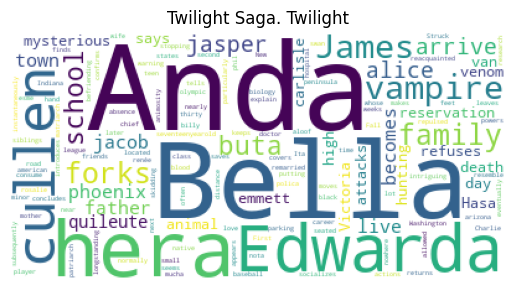

In [14]:
for index, row in docs.iterrows():
    wordcloud.generate(row['content'])
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title(index.replace(".txt", ""))
    plt.savefig("./wordclouds/{}".format(index.replace(".txt", ".png")))
    

### Topic modelling

In [15]:
def plot_top_words(model, feature_names, n_top_words, title, subplots):
    colors = ['forestgreen', 'lightskyblue', 'hotpink', 'turquoise', 'steelblue', 'crimson', 'seagreen', 'orange', 'brown', 'purple']
    fig, axes = plt.subplots(*subplots, figsize=(30, 15), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[-n_top_words:]
        top_features = feature_names[top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7, color=colors[topic_idx])
        ax.set_title(f"Topic {topic_idx + 1}", fontdict={"fontsize": 30})
        ax.tick_params(axis="both", which="major", labelsize=20)
        for i in "top right left".split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=40)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.savefig("./topics/{}.png".format(title.replace(" ", "_")))

In [16]:
def plot_documents(model, counts, n_componments, title):
    colors = ['forestgreen', 'lightskyblue', 'hotpink', 'turquoise', 'steelblue', 'crimson', 'seagreen', 'orange', 'brown', 'purple']
    docs_topic = pd.DataFrame(model.transform(counts), columns=[f'Topic {i+1}' for i in range(n_componments)])
    docs_topic.index = [file_name.replace(".txt", "") for file_name in files_names]
    plt.figure(figsize=(7, 4))
    left = [0] * len(docs_topic)
    for i, col in enumerate(docs_topic.columns):
        plt.barh(docs_topic.index, docs_topic[col], left=left, color=colors[i], label=col)
        left = [left[j] + docs_topic[col].iloc[j] for j in range(len(docs_topic))]
    plt.savefig("./topics/{}_docs.png".format(title), bbox_inches='tight')
    plt.close()

In [17]:
n_topics = 6
n_top_words = 20
feature_names = count_vectorizer.get_feature_names_out()
subplots = (2, 3)

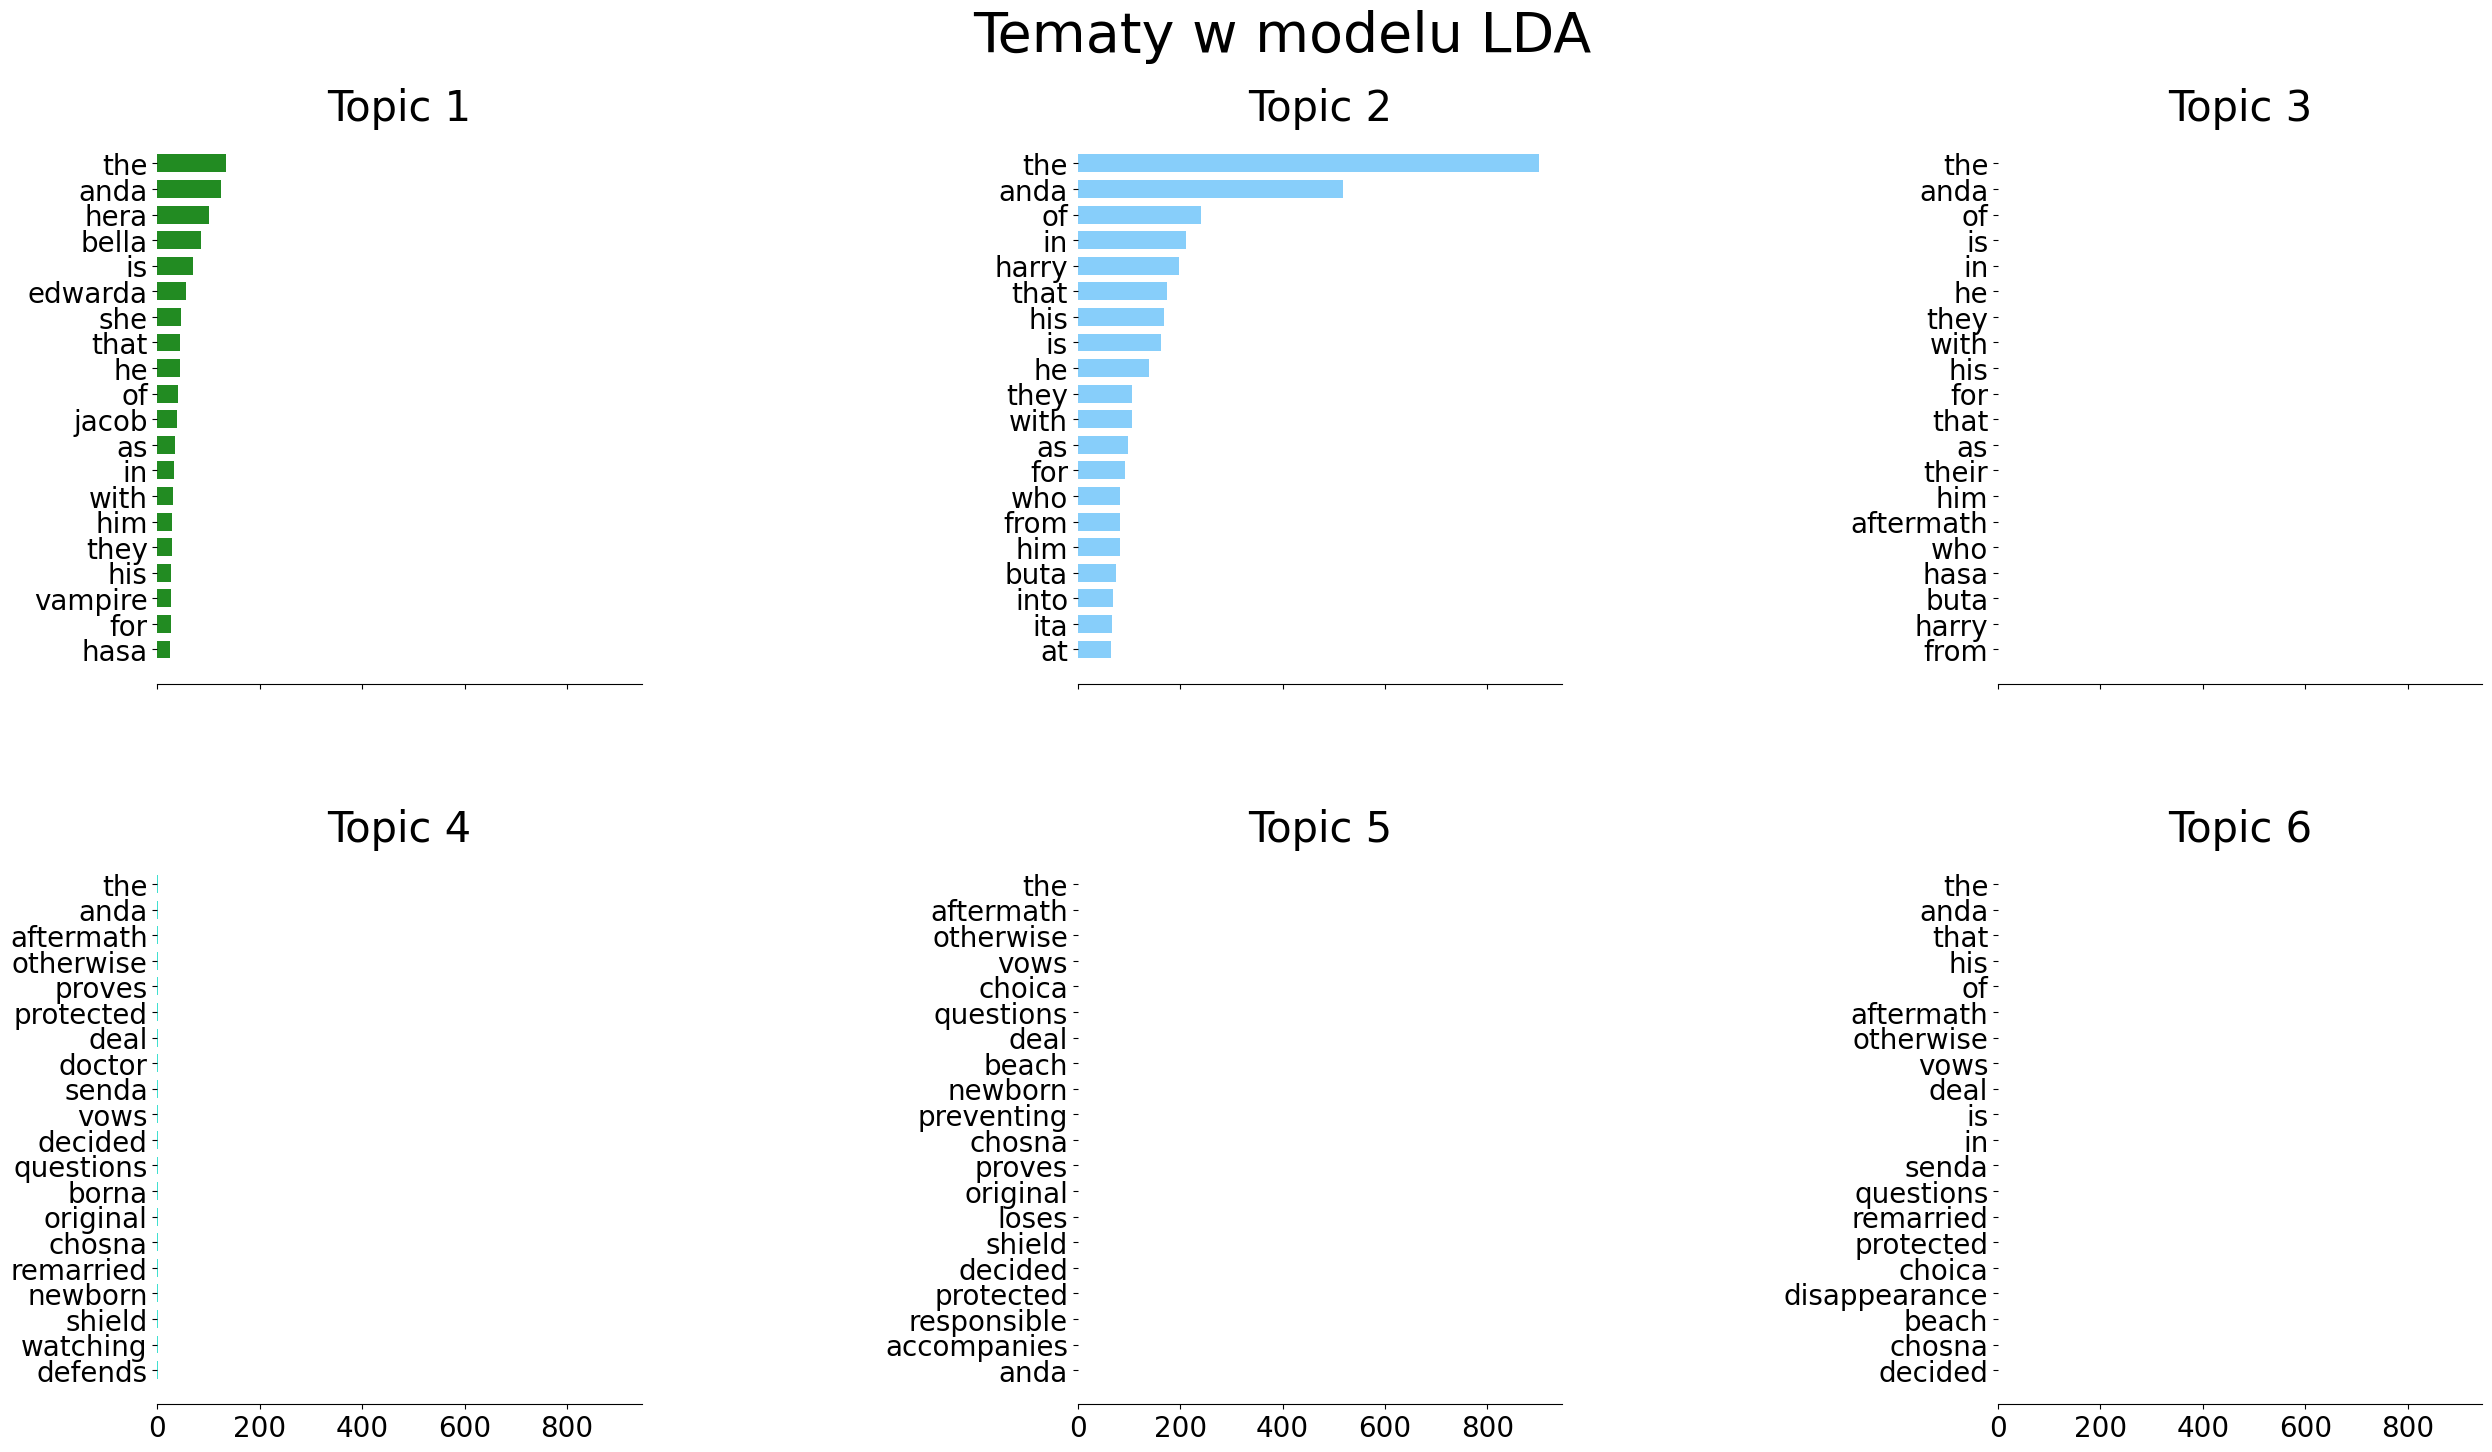

In [18]:
lda = LatentDirichletAllocation(n_components=n_topics, max_iter=1000, learning_method="online", learning_offset=50, random_state=0)
lda.fit(counts_tf)
plot_top_words(lda, feature_names, n_top_words, "Tematy w modelu LDA", subplots)
plot_documents(lda, counts_tf, n_topics, "Tematy w modelu LDA")

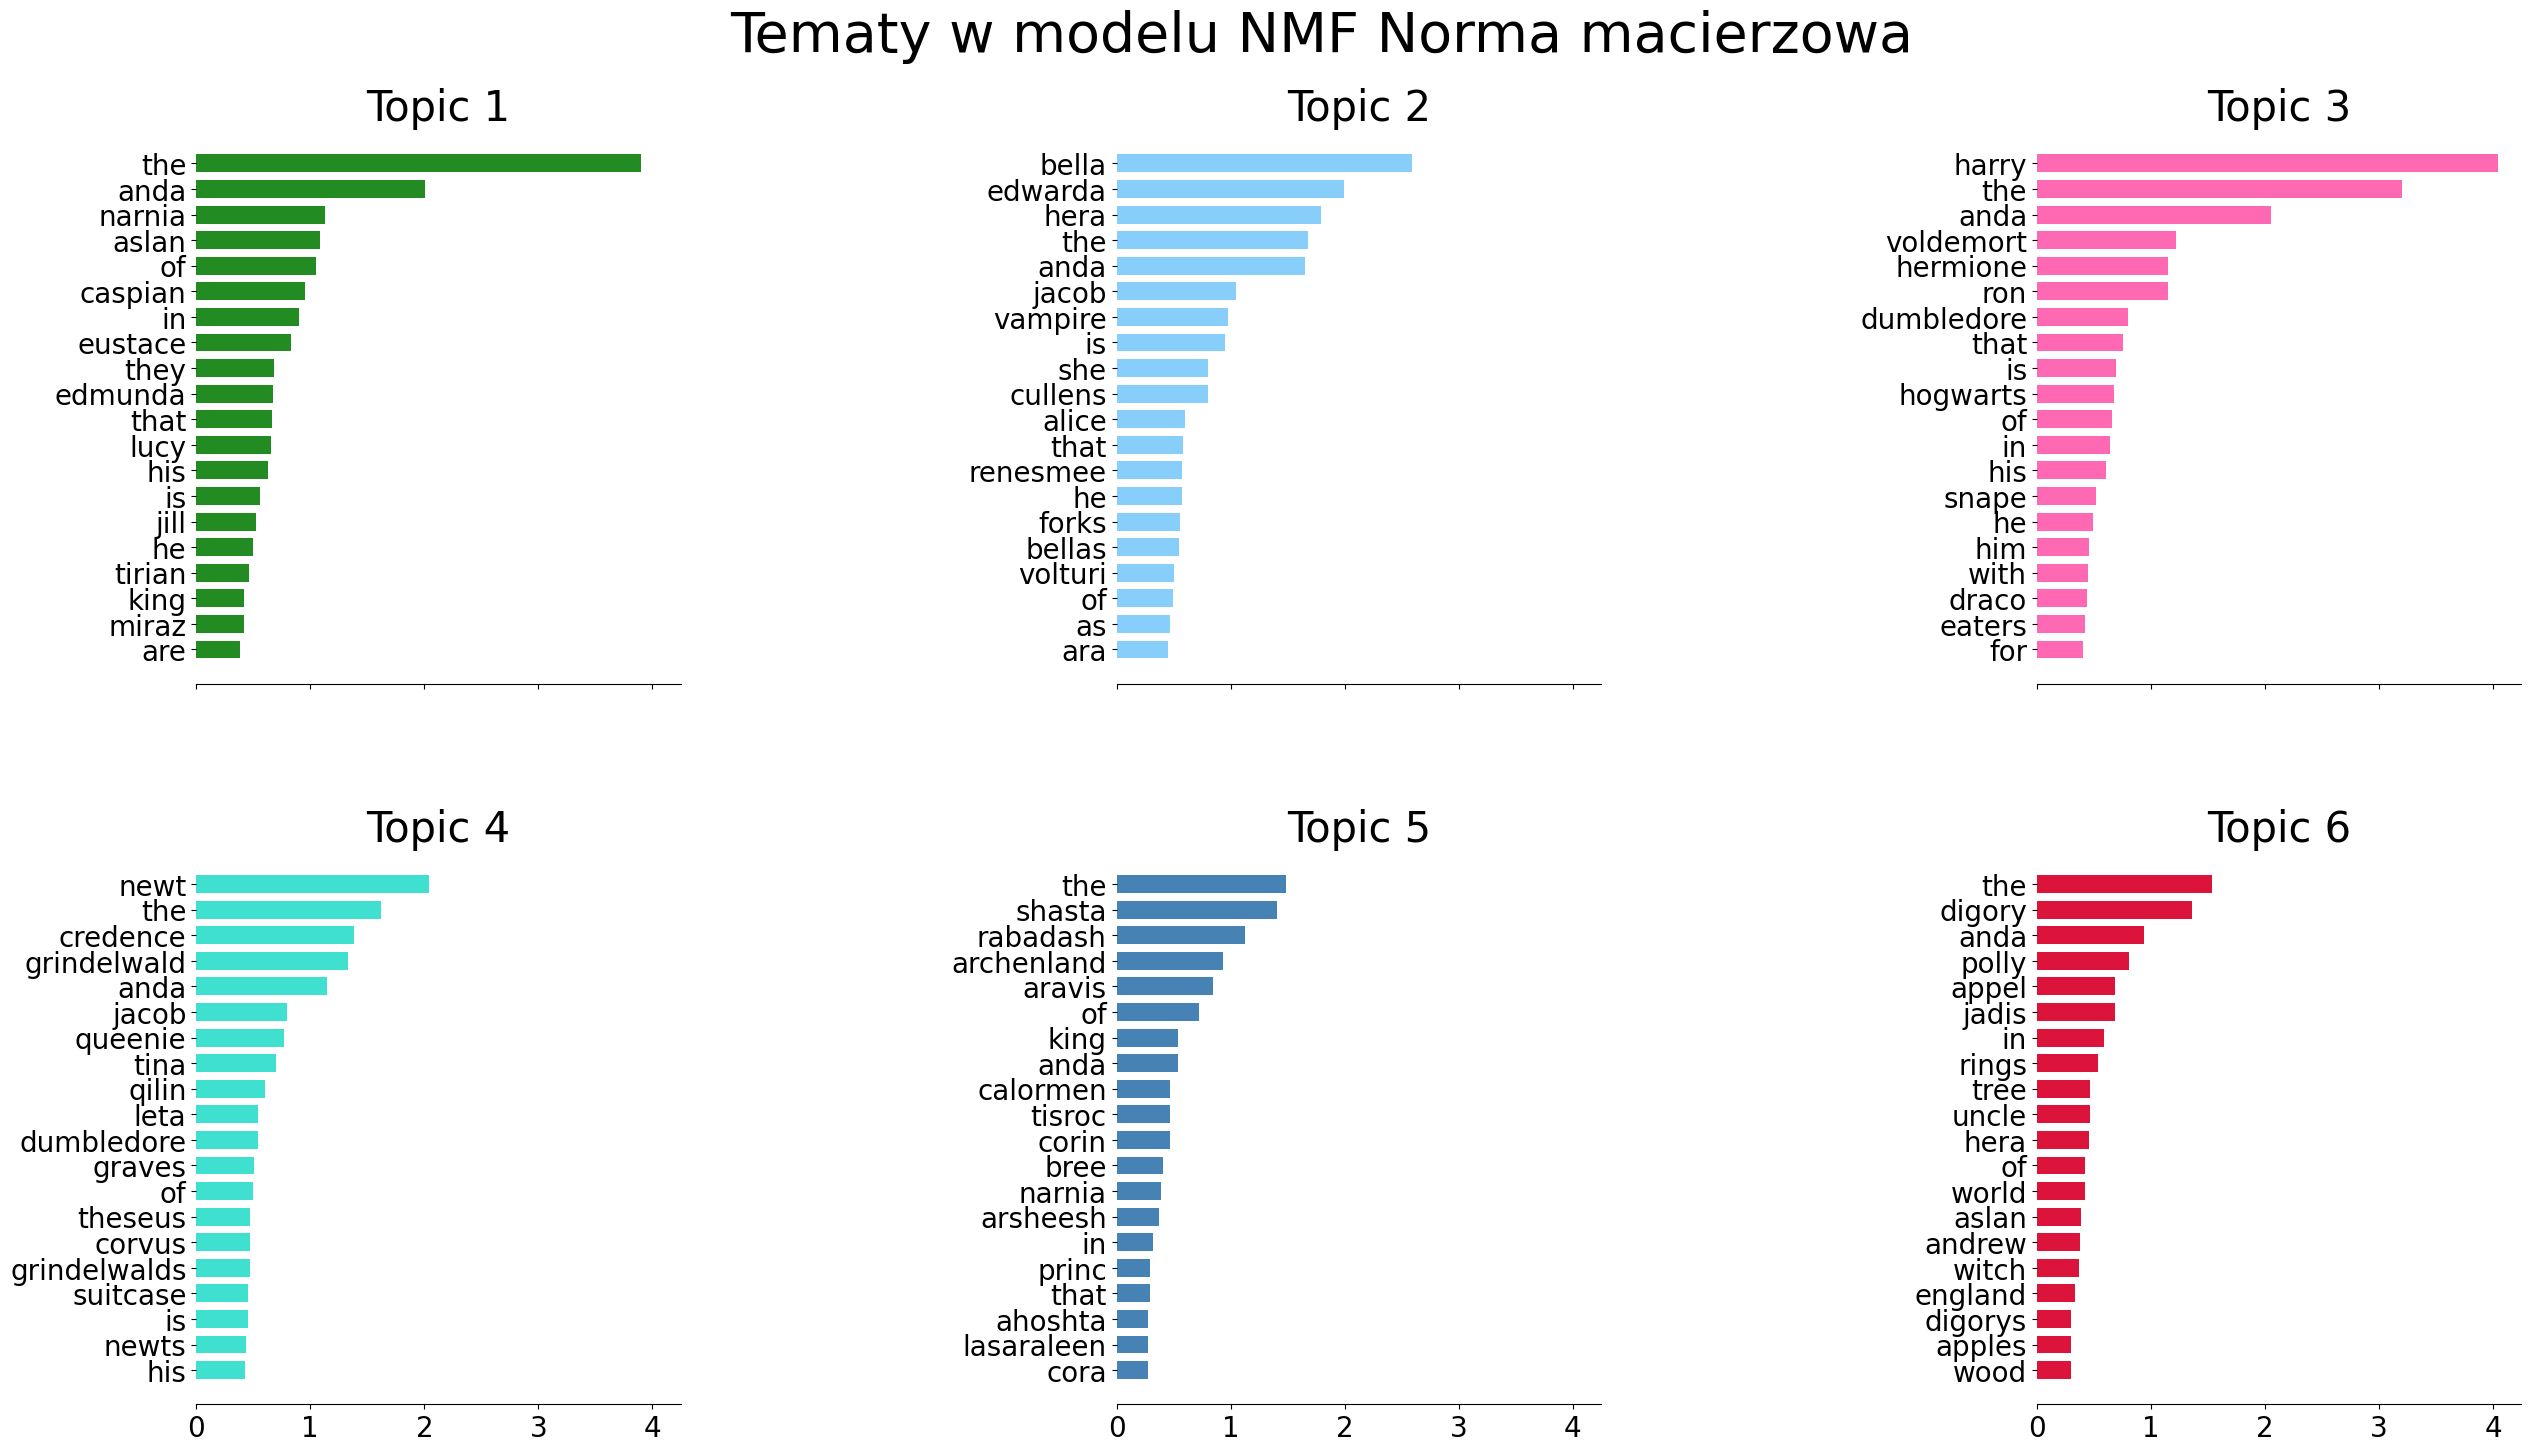

In [19]:
nmf_fn = NMF(n_components=n_topics, random_state=1, alpha_H=.00005, alpha_W=.00005, l1_ratio=.5)
nmf_fn.fit(counts_tfidf)
plot_top_words(nmf_fn, feature_names, n_top_words, "Tematy w modelu NMF Norma macierzowa", subplots)
plot_documents(nmf_fn, counts_tfidf, n_topics, "Tematy w modelu NMF Norma macierzowa")

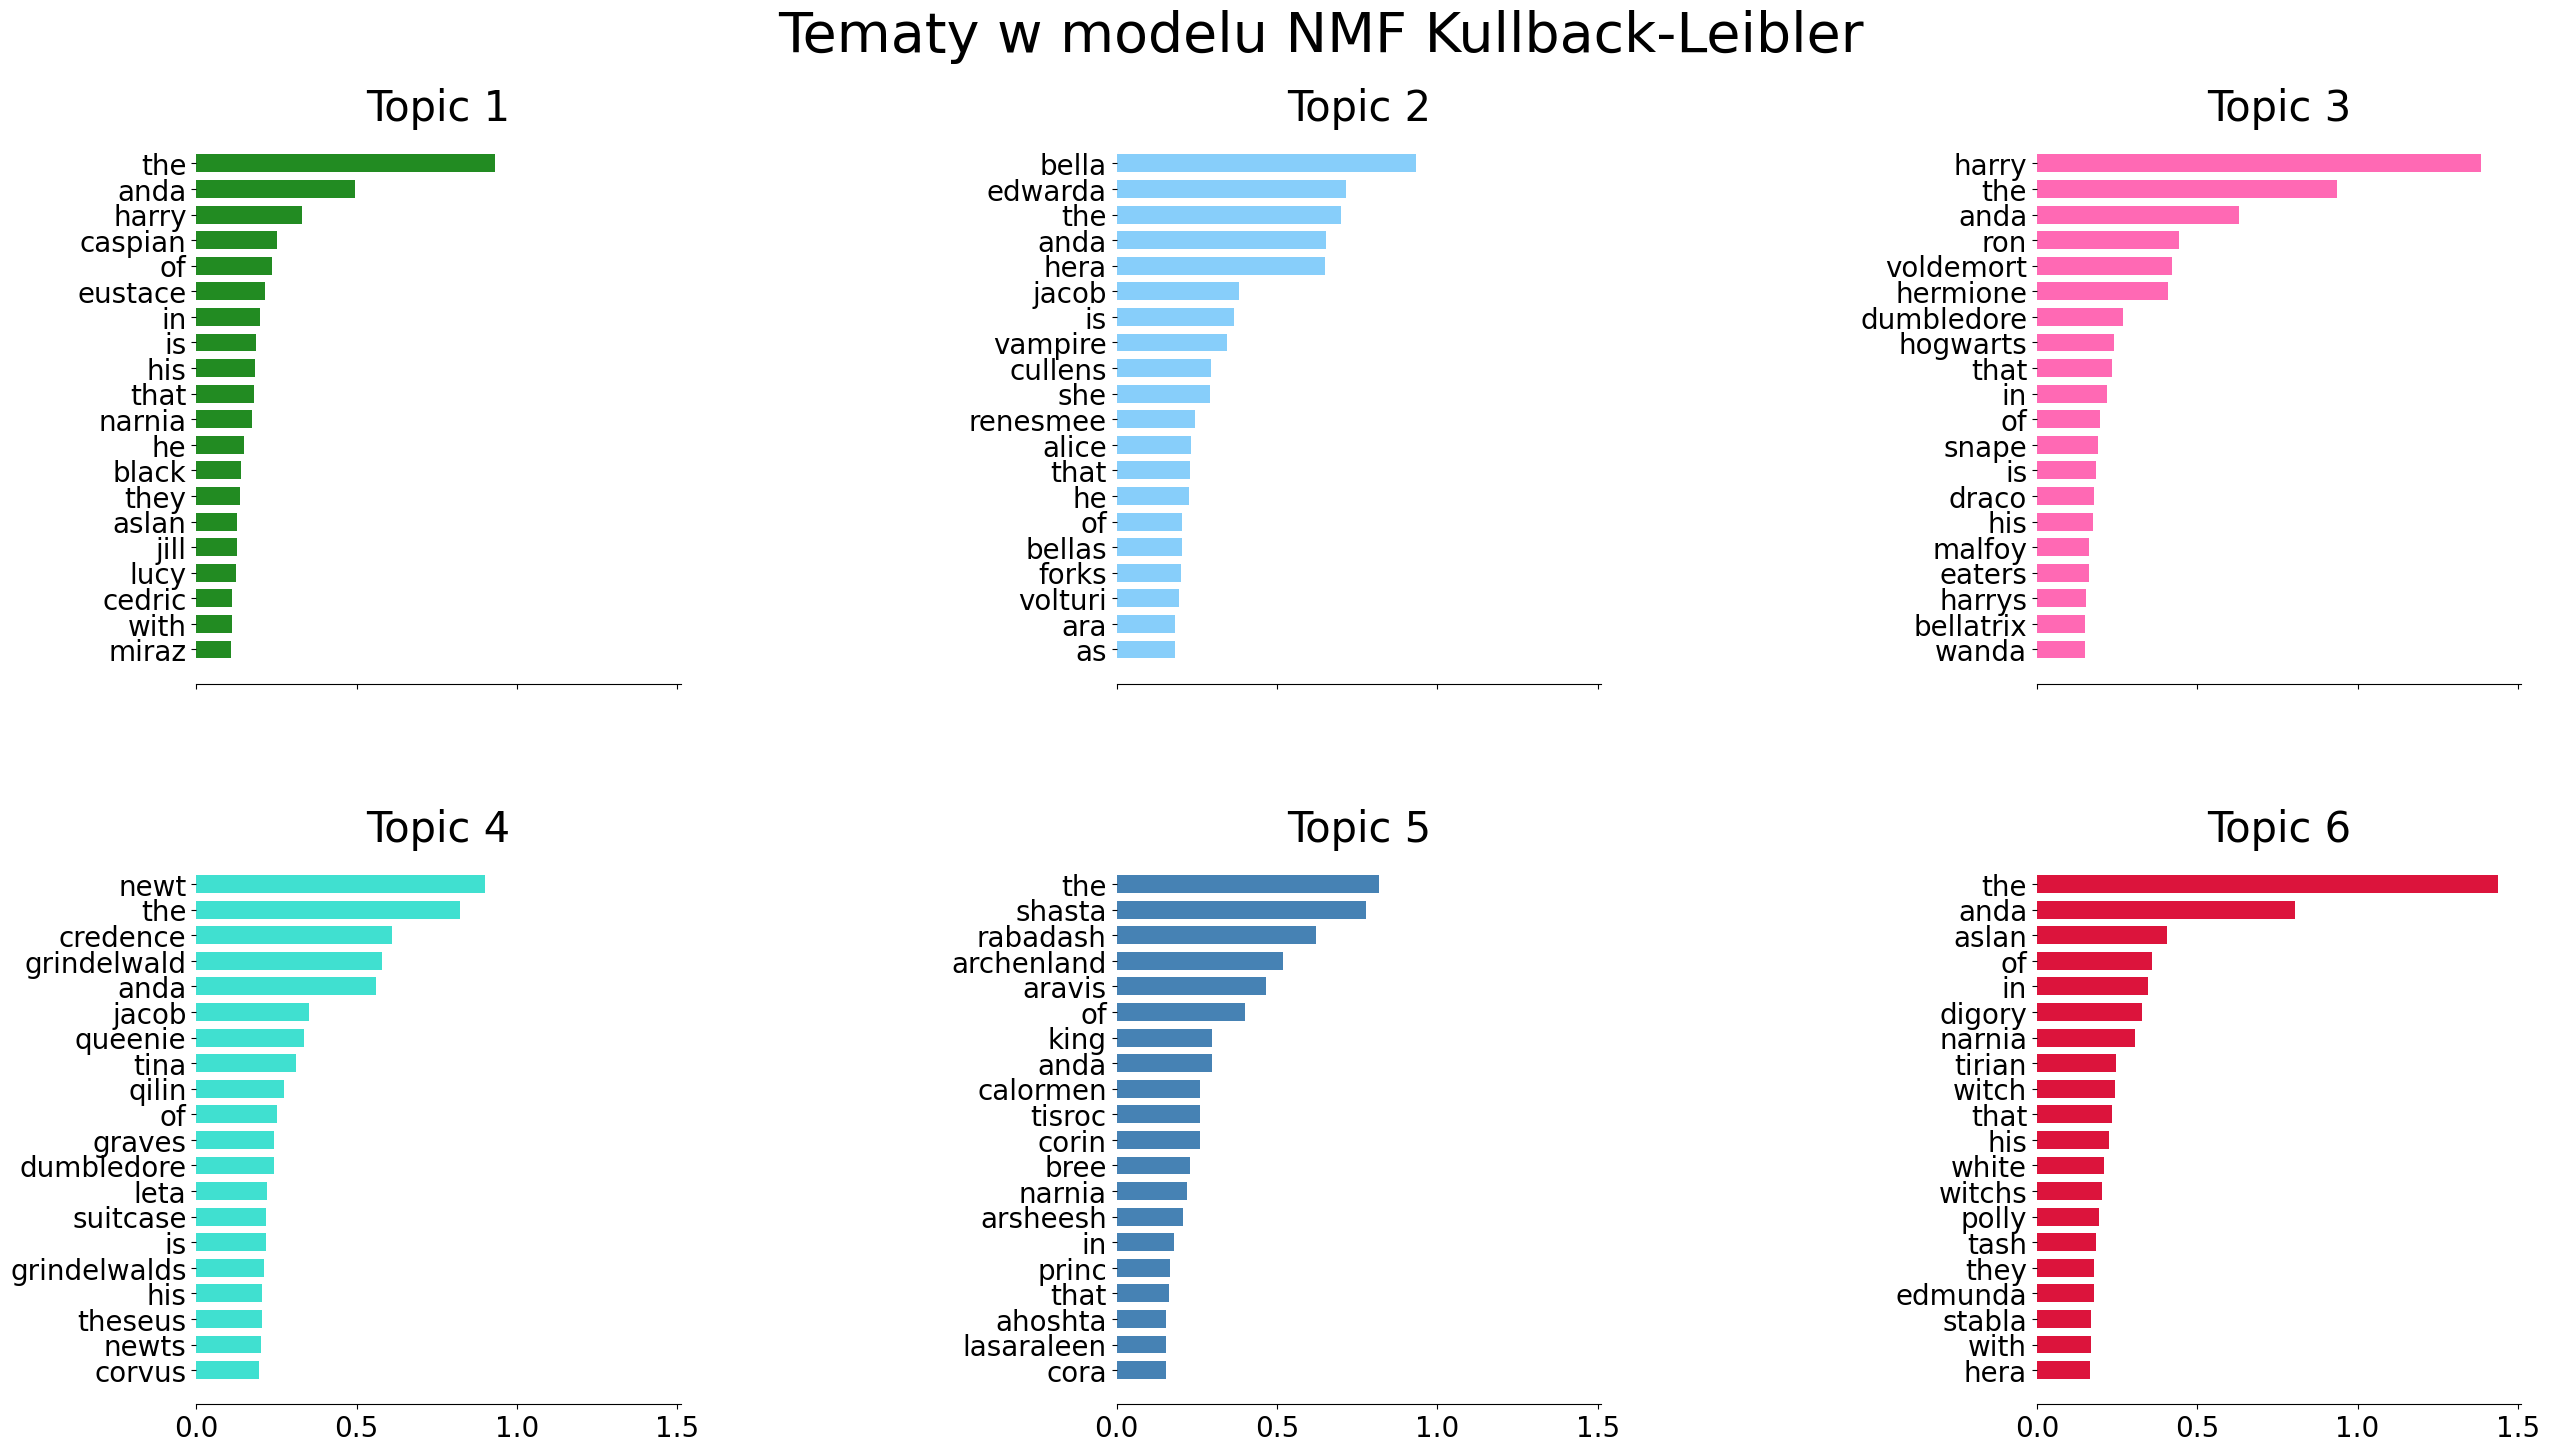

In [20]:
nmf_kl = NMF(
    n_components=n_topics,
    random_state=1,
    beta_loss='kullback-leibler',
    solver='mu',
    max_iter=1000,
    alpha_H=.00005,
    alpha_W=.00005,
    l1_ratio=.5
)
nmf_kl.fit(counts_tfidf)
plot_top_words(nmf_kl, feature_names, n_top_words, "Tematy w modelu NMF Kullback-Leibler", subplots)
plot_documents(nmf_kl, counts_tfidf, n_topics, "Tematy w modelu NMF Kullback-Leibler")


### Analiza skupień

In [21]:
def plot_dendrogram(model,title, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)
    plt.title(title)
    plt.savefig("./clusters/{}.png".format(title.replace(" ", "_")), bbox_inches='tight')
    plt.close()

In [22]:
cs = cosine_distances(counts_tfidf, counts_tfidf).flatten().reshape(len(files_names), len(files_names))
ed = euclidean_distances(counts_tfidf, counts_tfidf).flatten().reshape(len(files_names), len(files_names)) 

In [23]:
clustering_ed_complete = AgglomerativeClustering(
    n_clusters=3,
    metric='precomputed',
    linkage='complete',
    compute_distances=True,
).fit(ed)

plot_dendrogram(
    clustering_ed_complete,
    title="Dendrogram - odległość euklidesowa, metoda pełnego wiązania", 
    labels=[file_name.replace(".txt", "") for file_name in files_names], 
    orientation='left'
)
clustering_ed_complete.labels_


array([0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1])

In [24]:
clustering_cs_ward= AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward',
    compute_distances=True,
).fit(cs)

plot_dendrogram(
    clustering_cs_ward,
    title="Dendrogram - odległość kątowa, łączenie ward", 
    labels=[file_name.replace(".txt", "") for file_name in files_names], 
    orientation='left'
)
clustering_ed_complete.labels_


c:\Users\Monsarator\Desktop\Misc\studia\woj\hell\.venv\Lib\site-packages\scipy\cluster\hierarchy.py:810: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  return linkage(y, method='ward', metric='euclidean')


array([0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1])

### N-gramy

In [25]:
documents_tokenized = {}
for key in documents:
    documents_tokenized[key] = word_tokenize(documents[key], language='polish')
print(json.dumps(documents_tokenized, indent=4, ensure_ascii=False))

{
    "Chronicles of Narnia. Prince Caspian.txt": [
        "Petera",
        "susan",
        "Edmunda",
        "Anda",
        "lucy",
        "pevensie",
        "are",
        "magically",
        "whisked",
        "away",
        "From",
        "a",
        "british",
        "railway",
        "station",
        "a",
        "beach",
        "near",
        "an",
        "old",
        "Anda",
        "ruined",
        "castle",
        "they",
        "determine",
        "the",
        "ruina",
        "IS",
        "cair",
        "paravel",
        "where",
        "they",
        "once",
        "ruled",
        "as",
        "the",
        "kings",
        "Anda",
        "queens",
        "of",
        "narnia",
        "they",
        "discover",
        "the",
        "treasure",
        "vault",
        "where",
        "Peters",
        "sword",
        "Anda",
        "shield",
        "susans",
        "bow",
        "Anda",
        "arrows",
        "Anda",
     

In [26]:
for n in range(1, 4):
    fig, axes = plt.subplots(4, 5, figsize=(30, 15), tight_layout=True)
    axes = axes.flatten()
    for i, key in enumerate(documents_tokenized):
        if i < len(axes):
            n_grams = pd.Series(ngrams(documents_tokenized[key], n)).value_counts()
            n_grams[:5].plot.barh(ax=axes[i], title="{}-gramy w {}".format(n, key.replace(".txt", "")))
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.savefig("./ngrams/{}-grams.png".format(n), bbox_inches="tight")
    plt.close()

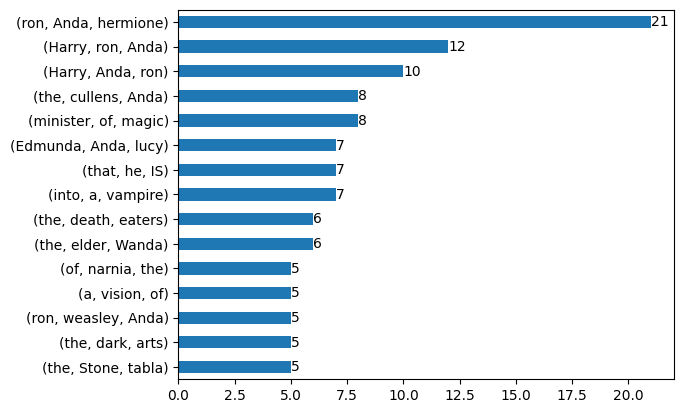

In [27]:
texts = " ".join(docs['content']).split(" ")
n_grams = pd.Series(ngrams(texts, 3)).value_counts()
ax = n_grams[:15].plot.barh()
plt.gca().invert_yaxis()
ax.bar_label(ax.containers[0], label_type='edge')
plt.show()